# Predicting Sentiment Using a Transformer

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Ch08_Attention/ec08_B_transformer/transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

In [257]:
# Uncomment if using Colab/Kaggle.
# !pip install contractions datasets deeplay deeptrack spacy

This notebook provides you with a complete code example that predicts the sentiment of movie reviews using a transformer encoder network.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>Note:</strong> This notebook contains the Code Example 8-B from the book  

**Deep Learning Crash Course**  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)

You can find the other notebooks on the [Deep Learning Crash Course GitHub page](https://github.com/DeepTrackAI/DeepLearningCrashCourse).
</div>

In [258]:
import pandas as pd
import numpy as np
import deeptrack as dt
import torch
from torch.utils.data import DataLoader
from datasets import Dataset


dataframe = pd.read_csv("jena_climate_2009_2016.csv", index_col=0)
data = dataframe.values
header = dataframe.columns.tolist()

In [259]:
start, days, daily_samples = 0, 14, 144
n_samples, n_features = data.shape[0], data.shape[1]
past_seq = 2 * daily_samples
lag = 72
temp_idx = 1  # Temperature (Celsius) index

in_sequences, targets = [], []
for i in range(past_seq, n_samples - lag, daily_samples):
    in_sequences.append(data[i - past_seq:i, [0,1,4,5,6,7,9,10,11,13]])
    targets.append(data[i + lag:i + lag + 1, temp_idx])
in_sequences, targets = np.asarray(in_sequences), np.asarray(targets)

print("Input sequences shape:", in_sequences.shape)  # (num_samples, past_seq, n_features)


sources = dt.sources.Source(inputs=in_sequences, targets=targets)
train_sources, val_sources = dt.sources.random_split(sources, [0.8, 0.2])



train_mean = np.mean([src["inputs"] for src in train_sources], axis=(0, 1))
train_std = np.std([src["inputs"] for src in train_sources], axis=(0, 1))

inputs_pipeline = (dt.Value(sources.inputs - train_mean) / train_std
                   >> dt.pytorch.ToTensor(dtype=torch.float))
targets_pipeline = (dt.Value(sources.targets - train_mean[temp_idx]) 
                    / train_std[temp_idx])


clim_train_dataset = dt.pytorch.Dataset(inputs_pipeline & targets_pipeline,
                                   inputs=train_sources)
clim_val_dataset = dt.pytorch.Dataset(inputs_pipeline & targets_pipeline,
                                 inputs=val_sources)

clim_train_dataset = Dataset.from_list([{'text': "", 'label': dat[1].item(), 'sequences': dat[0]} for dat in clim_train_dataset])
clim_val_dataset = Dataset.from_list([{'text': "", 'label': dat[1].item(), 'sequences': dat[0]} for dat in clim_val_dataset])


# train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=False)


Input sequences shape: (2918, 288, 10)


In [260]:
print(clim_train_dataset.shape)
print(clim_train_dataset[0].keys())
print(clim_train_dataset[0]["sequences"])
print(len(clim_train_dataset[0]["sequences"]))
print(clim_train_dataset[0]["label"])

(2335, 3)
dict_keys(['text', 'label', 'sequences'])
[[-0.23313778638839722, 1.301419973373413, -0.6526550054550171, 1.361843466758728, 1.4746763706207275, 0.8888127207756042, 1.4785617589950562, -1.2892318964004517, -0.9718037247657776, -0.4470488131046295], [-0.23192839324474335, 1.2801107168197632, -0.5601006150245667, 1.3269752264022827, 1.5174522399902344, 0.7966549396514893, 1.5231664180755615, -1.273266315460205, -0.6984608769416809, -0.9922088980674744], [-0.23313778638839722, 1.2410435676574707, -0.4705908000469208, 1.2649872303009033, 1.5245815515518188, 0.6922094225883484, 1.5278615951538086, -1.2410855293273926, -0.6138547658920288, -1.0651283264160156], [-0.22467200458049774, 1.1936894655227661, -0.3853433430194855, 1.1900850534439087, 1.5055700540542603, 0.5898118615150452, 1.5114283561706543, -1.1984273195266724, -0.6919527053833008, -1.329027533531189], [-0.21378743648529053, 1.1700124740600586, -0.3585512936115265, 1.1539254188537598, 1.4841821193695068, 0.5529487729072

## Using the IMDB Dataset

Start by downloading the Large Movie Review Dataset (often referred to as the IMDB dataset, as it’s available at https://huggingface.co/datasets/imdb). It contains 50,000 movie reviews, labeled as positive or negative. The dataset is divided into 25,000 reviews for training and 25,000 reviews for testing.

Download the IMDB dataset ...

In [261]:
from datasets import load_dataset

dataset = load_dataset("imdb")

INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/imdb/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/stanfordnlp/imdb/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/README.md "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb.py "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/stanfordnlp/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/imdb.py "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/imdb/imdb.py "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/datasets/imdb/resolve/e6281661ce1c48d982bc483cf8a173c1bbeb5d31/.huggingfac

... splitting the training and validation datasets ...

In [262]:
split = dataset["train"].train_test_split(test_size=0.2,
                                          stratify_by_column="label", seed=42)
train_dataset, val_dataset = split["train"], split["test"]

In [263]:
print(train_dataset)
print(train_dataset.shape)
print(train_dataset[0].keys())
print(train_dataset[0]["sequences"])
print(len(train_dataset[0]["sequences"]))
print(train_dataset[0]["label"])

Dataset({
    features: ['text', 'label'],
    num_rows: 20000
})
(20000, 2)
dict_keys(['text', 'label'])


KeyError: 'sequences'

... and print some example reviews.

In [ ]:
# import numpy as np
# import pandas as pd

# samples = train_dataset.select(np.random.randint(0, len(train_dataset), 3))
# texts, labels = samples["text"], samples["label"]

# df = pd.DataFrame({"Text": texts, "Label": labels})
# styled_df = df.style.set_properties(**{"text-align": "left"}).set_table_styles(
#     [{"selector": "th", "props": [("text-align", "center")]}]
# )
# with pd.option_context("display.max_colwidth", None):
#     display(styled_df)

### Preprocessing the Reviews

Implement a function to tokenize a sentence ...

In [ ]:
import contractions, re, spacy, unicodedata

tokenizers = {"eng": spacy.blank("en"), "spa": spacy.blank("es")}

regular_expression = r"^[a-zA-Z0-9áéíóúüñÁÉÍÓÚÜÑ.,!?¡¿/:()]+$"
pattern = re.compile(unicodedata.normalize("NFC", regular_expression))

def tokenize(text, lang="eng"):
    """Tokenize text."""
    swaps = {"’": "'", "‘": "'", "“": '"', "”": '"', "´": "'", "´´": '"'}
    for old, new in swaps.items():
        text = text.replace(old, new)
    text = contractions.fix(text) if lang == "eng" else text
    tokens = tokenizers[lang](text)
    return [token.text for token in tokens if pattern.match(token.text)]

### Building a Vocabulary

Implement a class to represent a vocabulary ...

In [ ]:
class Vocab:
    """Vocabulary as callable dictionary."""

    def __init__(self, vocab_dict, unk_token="<unk>"):
        """Initialize vocabulary."""
        self.vocab_dict, self.unk_token = vocab_dict, unk_token
        self.default_index = vocab_dict.get(unk_token, -1)
        self.index_to_token = {idx: token for token, idx in vocab_dict.items()}

    def __call__(self, token_or_tokens):
        """Return the index(es) for given token or list of tokens."""
        if not isinstance(token_or_tokens, list):
            return self.vocab_dict.get(token_or_tokens, self.default_index)
        else:
            return [self.vocab_dict.get(token, self.default_index)
                    for token in token_or_tokens]

    def set_default_index(self, index):
        """Set default index for unknown tokens."""
        self.default_index = index

    def lookup_token(self, index_or_indices):
        """Retrieve token corresponding to given index or list of indices."""
        if not isinstance(index_or_indices, list):
            return self.index_to_token.get(int(index_or_indices),
                                           self.unk_token)
        else:
            return [self.index_to_token.get(int(index), self.unk_token)
                    for index in index_or_indices]

    def get_tokens(self):
        """Return a list of tokens ordered by their index."""
        tokens = [None] * len(self.index_to_token)
        for index, token in self.index_to_token.items():
            tokens[index] = token
        return tokens

    def __iter__(self):
        """Iterate over the tokens in the vocabulary."""
        return iter(self.vocab_dict)

    def __len__(self):
        """Return the number of tokens in the vocabulary."""
        return len(self.vocab_dict)

    def __contains__(self, token):
        """Check if a token is in the vocabulary."""
        return token in self.vocab_dict

... implement a function to build vocabulary from an iterator ...

In [ ]:
from collections import Counter

def build_vocab_from_iterator(iterator, specials=None, min_freq=1):
    """Build vocabulary from an iterator over tokenized sentences."""
    token_freq = Counter(token for tokens in iterator for token in tokens)
    vocab, index = {}, 0
    if specials:
        for token in specials:
            vocab[token] = index
            index += 1
    for token, freq in token_freq.items():
        if freq >= min_freq:
            vocab[token] = index
            index += 1
    return vocab

... create a vocabulary ...

In [ ]:
def imdb_iterator(dataset):
    """Iterate over the IMDB dataset."""
    for sample in dataset:
        yield tokenize(sample["text"])

vocab_dict = build_vocab_from_iterator(imdb_iterator(train_dataset),
                                       specials=["<unk>"], min_freq=10)
vocab = Vocab(vocab_dict, unk_token="<unk>")
vocab.set_default_index(vocab(vocab.unk_token))

... and preprocess the training, validation, and testing datasets.

In [ ]:
def preprocessing(sample):
    """Preprocess a movie review."""
    sentence = sample["text"]
    tokens = tokenize(unicodedata.normalize("NFC", sentence))
    sequence_of_indices = vocab(tokens)
    sample.update({"sequences": sequence_of_indices})
    return sample

train_dataset = train_dataset.map(preprocessing)
val_dataset = val_dataset.map(preprocessing)
# test_dataset = dataset["test"].map(preprocessing)

Map: 100%|██████████| 5000/5000 [00:03<00:00, 1364.34 examples/s]


(20000, 3)
dict_keys(['text', 'label', 'sequences'])


# Defining the Data Loaders

In [ ]:
print(train_dataset.shape)
print(train_dataset[0].keys())

(20000, 3)
dict_keys(['text', 'label', 'sequences'])


In [ ]:
import torch
from torch.utils.data import DataLoader
from torch_geometric.data import Data

def collate(batch_of_sequences):
    """Prepare a batch of sequences for the model to process."""
    sequences, labels, batch_indices = [], [], []
    for batch_index, sample in enumerate(batch_of_sequences):
        sequence = torch.tensor(sample["sequences"])
        sequences.append(sequence)
        batch_indices.append(torch.ones_like(sequence, dtype=torch.long)
                             * batch_index)
        label = torch.tensor(sample["label"])
        labels.append(label)
    return Data(sequences=torch.cat(sequences),
                batch_indices=torch.cat(batch_indices),
                y=torch.tensor(labels).float())

# train_dataloader = \
#     DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate)
# val_dataloader = \
#     DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate)
train_dataloader = \
    DataLoader(clim_train_dataset, batch_size=8, shuffle=True, collate_fn=collate)
val_dataloader = \
    DataLoader(clim_val_dataset, batch_size=8, shuffle=False, collate_fn=collate)
# test_dataloader = \
#     DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate)

## Building a Transformer Encoder Layer

Prepare a class to implement a multi-head attention layer ...

In [ ]:
import deeplay as dl

class MultiHeadAttentionLayer(dl.DeeplayModule):
    """Multi-head attention layer with masking."""

    def __init__(self, num_features, num_heads):
        """Initialize multi-head attention."""
        super().__init__()
        self.num_features, self.num_heads = num_features, num_heads
        self.head_dim = num_features // num_heads  # Must be integer
        # print(f"num_features: {num_features}, num_heads: {num_heads}, head_dim: {self.head_dim}")

        self.Wq = dl.Layer(torch.nn.Linear, num_features, num_features)
        self.Wk = dl.Layer(torch.nn.Linear, num_features, num_features)
        self.Wv = dl.Layer(torch.nn.Linear, num_features, num_features)
        self.Wout = dl.Layer(torch.nn.Linear, num_features, num_features)

    def forward(self, in_sequence, batch_indices):
        """Apply the multi-head attention mechanism to the input sequence."""
        seq_len, embed_dim = in_sequence.shape
        Q = self.Wq(in_sequence)
        # print("Q shape after linear transformation:", Q.shape)
        Q = Q.view(seq_len, self.num_heads, self.head_dim).permute(1, 0, 2)
        K = self.Wk(in_sequence)
        K = K.view(seq_len, self.num_heads, self.head_dim).permute(1, 0, 2)
        V = self.Wv(in_sequence)
        V = V.view(seq_len, self.num_heads, self.head_dim).permute(1, 0, 2)

        attn_scores = (torch.matmul(Q, K.transpose(-2, -1))
                       / (self.head_dim ** 0.5))

        attn_mask = torch.eq(batch_indices.unsqueeze(1),
                             batch_indices.unsqueeze(0))
        attn_mask = attn_mask.unsqueeze(0)
        attn_scores = attn_scores.masked_fill(attn_mask == False,
                                              float("-inf"))

        attn_weights = torch.nn.functional.softmax(attn_scores, dim=-1)
        attn_output = torch.matmul(attn_weights, V)
        attn_output = attn_output.permute(1, 0, 2).contiguous()
        attn_output = attn_output.view(seq_len, self.num_features)
        return self.Wout(attn_output)

... and a class to implement a transformer encoder layer ...

In [ ]:
from torch_geometric.nn.norm import LayerNorm

class TransformerEncoderLayer(dl.DeeplayModule):
    """Transformer encoder layer."""

    def __init__(self, num_features, num_heads, feedforward_dim, dropout=0.0):
        """Initialize transformer encoder layer."""
        super().__init__()

        self.self_attn = MultiHeadAttentionLayer(num_features, num_heads)
        self.attn_dropout = dl.Layer(torch.nn.Dropout, dropout)
        self.attn_skip = dl.Add()
        self.attn_norm = dl.Layer(LayerNorm, num_features, eps=1e-6)

        self.feedforward = dl.Sequential(
            dl.Layer(torch.nn.Linear, num_features, feedforward_dim),
            dl.Layer(torch.nn.ReLU),
            dl.Layer(torch.nn.Linear, feedforward_dim, num_features),
        )
        self.feedforward_dropout = dl.Layer(torch.nn.Dropout, dropout)
        self.feedforward_skip = dl.Add()
        self.feedforward_norm = dl.Layer(LayerNorm, num_features, eps=1e-6)

    def forward(self, in_sequence, batch_indices):
        """Refine sequence via attention and feedforward layers."""
        attns = self.self_attn(in_sequence, batch_indices)
        attns = self.attn_dropout(attns)
        attns = self.attn_skip(in_sequence, attns)
        attns = self.attn_norm(attns, batch_indices)

        out_sequence = self.feedforward(attns)
        out_sequence = self.feedforward_dropout(out_sequence)
        out_sequence = self.feedforward_skip(attns, out_sequence)
        out_sequence = self.feedforward_norm(out_sequence, batch_indices)

        return out_sequence

## Building a Transformer Encoder Model

Build a class to implement a transformer encoder model ...

In [ ]:
class TransformerEncoderModel(dl.DeeplayModule):
    """Transformer encoder model."""

    def __init__(self, vocab_size, num_features, num_heads, feedforward_dim,
                 num_layers, out_dim, dropout=0.0):
        """Initialize transformer encoder model."""
        super().__init__()
        self.num_features = num_features

        self.embedding = dl.Layer(torch.nn.Linear, vocab_size, num_features)

        self.pos_encoder = dl.IndexedPositionalEmbedding(num_features)
        self.pos_encoder.dropout.configure(p=dropout)

        self.transformer_block = dl.LayerList()
        for _ in range(num_layers):
            self.transformer_block.append(TransformerEncoderLayer(
                    num_features, num_heads, feedforward_dim, dropout=dropout,
            ))

        self.out_block = dl.Sequential(
            dl.Layer(torch.nn.Dropout, dropout),
            dl.Layer(torch.nn.Linear, num_features, num_features // 2),
            dl.Layer(torch.nn.ReLU),
            dl.Layer(torch.nn.Linear, num_features // 2, out_dim),
            dl.Layer(torch.nn.Sigmoid),
        )

    def forward(self, dict):
        """Predict sentiment of movie reviews."""
        in_sequence, batch_indices = dict["sequences"], dict["batch_indices"][:,0]
        # print("Input sequence shape:", in_sequence.shape)
        # print("Batch indices shape:", batch_indices.shape)
        # print(batch_indices[287])
        # print(batch_indices[288])

        embeddings = self.embedding(in_sequence) * self.num_features ** 0.5
        # print("Embeddings shape:", embeddings.shape)
        pos_embeddings = self.pos_encoder(embeddings, batch_indices)
        # print("Positional embeddings shape:", pos_embeddings.shape)

        out_sequence = pos_embeddings
        for transformer_layer in self.transformer_block:
            out_sequence = transformer_layer(out_sequence, batch_indices)

        batch_size = torch.max(batch_indices) + 1
        aggregates = torch.zeros(batch_size, self.num_features,
                                 device=out_sequence.device)
        for batch_index in torch.unique(batch_indices):
            mask = batch_indices == batch_index
            aggregates[batch_index] = out_sequence[mask].mean(dim=0)

        pred_sentiment = self.out_block(aggregates).squeeze()
        return pred_sentiment

... instantiate the transformer encoder model ...

In [ ]:
M = 12 * 4

model = TransformerEncoderModel(
    vocab_size=14, num_features=M, num_heads=12, feedforward_dim=512,
    num_layers=4, out_dim=1, dropout=0.1,
).create()

... and print it out.

In [ ]:
# print(model)

## Loading Pretrained Embeddings

Download the GloVe embeddings ...

In [ ]:
# import os
# from torchvision.datasets.utils import download_url, extract_archive

# glove_folder = ".glove_cache"
# if not os.path.exists(glove_folder):
#     os.makedirs(glove_folder, exist_ok=True)
#     url = "https://nlp.stanford.edu/data/glove.42B.300d.zip"
#     download_url(url, glove_folder)
#     zip_filepath = os.path.join(glove_folder, "glove.42B.300d.zip")
#     extract_archive(zip_filepath, glove_folder)
#     os.remove(zip_filepath)

... implement a function to load the GloVe embeddings ...

In [ ]:
# def load_glove_embeddings(glove_file):
#     """Load GloVe embeddings."""
#     glove_embeddings = {}
#     with open(glove_file, "r", encoding="utf-8") as file:
#         for line in file:
#             values = line.split()
#             word = values[0]
#             glove_embeddings[word] = np.round(
#                 np.asarray(values[1:], dtype="float32"), decimals=6,
#             )
#     return glove_embeddings

... implement a function to get GloVe embeddings for a vocabulary ...

In [ ]:
# def get_glove_embeddings(vocab, glove_embeddings, embed_dim):
#     """Get GloVe embeddings for a vocabulary."""
#     embeddings = torch.zeros((len(vocab), embed_dim), dtype=torch.float32)
#     for i, token in enumerate(vocab):
#         embedding = glove_embeddings.get(token)
#         if embedding is None:
#             embedding = glove_embeddings.get(token.lower())
#         if embedding is not None:
#             embeddings[i] = torch.tensor(embedding, dtype=torch.float32)
#     return embeddings

... ad add the GloVe pretrained embeddings.

In [ ]:
# glove_file = os.path.join(glove_folder, "glove.42B.300d.txt")
# glove_embed, embed_dim = load_glove_embeddings(glove_file), 300

# model.embedding.weight.data = \
#     get_glove_embeddings(vocab.get_tokens(), glove_embed, embed_dim)
# model.embedding.weight.requires_grad = False

## Training the Model

Compile the model ...

In [ ]:
classifier = dl.Regressor(
    model=model, optimizer=dl.AdamW(lr=1e-4),
).create()

... and train it.

In [ ]:
trainer = dl.Trainer(max_epochs=5, accelerator="cpu")  ###
trainer.fit(classifier, train_dataloader, val_dataloader)

┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss                  │      0 │ eval  │     0 │
│ 1 │ train_metrics │ MetricCollection        │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection        │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection        │      0 │ train │     0 │
│ 4 │ model         │ TransformerEncoderModel │  479 K │ train │     0 │
│ 5 │ optimizer     │ AdamW                   │      0 │ train │     0 │
└───┴───────────────┴─────────────────────────┴────────┴───────┴───────┘

Trainable params: 239 K                                                                                            
Non-trainable params: 240 K                                                                                        
Total params: 479 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 79                                                                                          
Modules in eval mode: 1                                                                                            
Total FLOPs: 0

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
c:\Users\jojac\anaconda3\envs\stoch\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:534: Found 1 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 4: 100%|██████████| 292/292 [05:05<00:00,  0.96it/s, v_num=75, train_loss_step=0.424, val_loss_step=0.731, val_loss_epoch=0.596, train_loss_epoch=0.593]


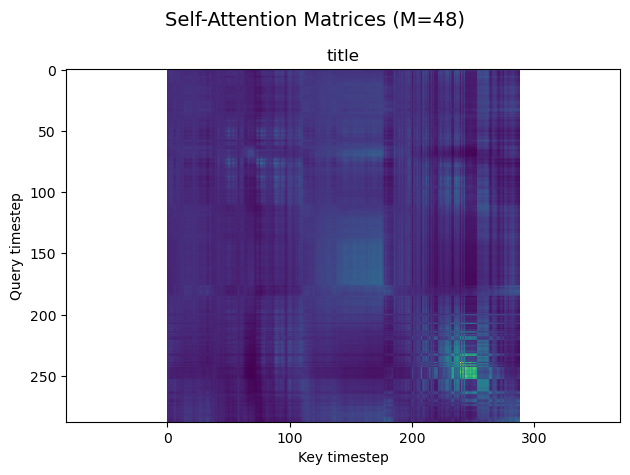

In [ ]:
import matplotlib.pyplot as plt


def get_attention_matrix(x):
    with torch.no_grad():
        scores = torch.matmul(x, x.transpose(-2, -1)) / np.sqrt(x.shape[2])  # (batch, seq_len, seq_len)
        attM = torch.softmax(scores, dim=-1)
        return attM
    

data = torch.tensor(clim_train_dataset[811]["sequences"]).unsqueeze(0)  # Add batch dimension
x = classifier.model.embedding(data)


mat = get_attention_matrix(x).squeeze()
im = plt.imshow(mat, cmap="viridis", aspect="auto")
plt.title("title", fontsize=12)
plt.xlabel("Key timestep")
plt.ylabel("Query timestep")


plt.axis('equal')  
plt.suptitle(f"Self-Attention Matrices (M={M})", fontsize=14)
plt.tight_layout()
plt.show()

## Evaluating the Trained Model

Test the trained model ... ...

In [ ]:
test_results = trainer.test(classifier, test_dataloader)

NameError: name 'test_dataloader' is not defined

... and display the model’s prediction on some reviews.

In [ ]:
import random

classifier.model.eval()

texts, labels, predictions = [], [], []
for idx in random.sample(range(len(test_dataset)), 3):
    sample = test_dataset[idx]
    input_sequence = torch.tensor(vocab(tokenize(sample["text"]))).long()
    test_input = {
        "sequences": input_sequence,
        "batch_indices": torch.zeros_like(input_sequence, dtype=torch.long),
    }
    probability = classifier.model(test_input)
    prediction = probability > 0.5

    texts.append(sample["text"])
    labels.append(sample["label"])
    predictions.append(prediction.item() * 1)

df = pd.DataFrame({"text": texts, "label": labels, "prediction": predictions})
styled_df = df.style.set_properties(**{"text-align": "left"}).set_table_styles(
    [{"selector": "th", "props": [("text-align", "center")]}]
)
with pd.option_context("display.max_colwidth", None):
    display(styled_df)

,text,label,prediction
0,"I was truly and wonderfully surprised at ""O' Brother, Where Art Thou?"" The video store was out of all the movies I was planning on renting, so then I came across this. I came home and as I watched I became engrossed and found myself laughing out loud. The Coen's have made a magnificiant film again. But I think the first time you watch this movie, you get to know the characters. The second time, now that you know them, you laugh sooo hard it could hurt you. I strongly would reccomend ANYONE seeing this because if you are not, you are truly missing a film gem for the ages. 10/10",1,1
1,"I tried watching this movie, but I didn't make it past the first 15 minutes. It's a terrible disappointment, considering the cast, but I can't look past the fact that the dialogue is in English and some of the actors pretending to be Indian are not even close (read: Kristin Kreuk). Considering that India alone has 1/6th of the world's population and one of the biggest movie industries, I don't think it would have been hard for the film-makers to have found an excellent Indian actress to play the part. And I don't say so because of some blind patriotism, but because it's absolutely and totally absurd for a non-Indian to play the role of an Indian/Pakistani. Now some people say that 'as long as she's convincing who cares?' but my point is exactly that she's NOT convincing and never can be - not due to her acting skills, but due to her ethnicity. For example, however good an actor Tom Hanks may be, he'll never be able to play an Australian Aborigine!But that is still minor to the biggest faux pas the film-makers made: having the dialogue in English. It totally destroys the mood, as well as any semblance of authenticity. Had the same movie been made in native languages (Hindi, Urdu, Punjabi) with English subtitles, this may have been an excellent movie. Unfortunately, as things stand, I would not recommend anyone seeing it, apart from film students who want to study ""What not to do"" in movies.",0,0
2,"Despite this production having received a number of poor reviews, it actually holds up quite well for its age. Note also that it is not a BBC programme, it was simply licensed to them by Granada Ventures when the Jane Austen collection was released on DVD.So how does it compare with other adaptations of the same novel? The most well-known version these days is the 1995 film with Amanda Root as Anne Elliott and Ciaran Hinds as Captain Frederick Wentworth. That film was of course shorter but a good snapshot of the story - the earlier version, with Ann Firbank and Bryan Marshall in the same roles, had four hours to tell the story and moved at a more leisurely pace.Firbank is a good ten years too old for her role, but she is very good - Marshall is excellent as Wentworth, a man disappointed in love, and bitter about interference. And hidden in the cast are people who also contribute - Michael Culver, later seen in Cadfael, as Harvill; Richard Vernon, later seen in the Hitchhikers Guide to the Galaxy, as Admiral Croft; Noel Dyson, earlier in Coronation Street, as Mrs Musgrove.One criticism I do have is that the hairstyles are a bit distracting, and that the costumes are awful! Still, this shouldn't detract from a hugely enjoyable Austen adaptation.",1,1
